# Entrenamiento de modelo de predicción de puntuación


## Importación de librerias necesarias


In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")


JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [3]:
import numpy as np
import pandas as pd
import sys
import os
import shutil
import tensorflow as tf
import tensorflow_io as tfio
from pyspark.sql import functions as F, types as T, DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.feature import VectorAssembler


2025-10-19 20:01:39.825694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-19 20:01:39.837268: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-19 20:01:39.840548: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-19 20:01:39.849692: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-19 20:01:41.936738: W tensorflow/compiler/tf2

In [4]:
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA built: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[2.0, 0.0], [0.0, 2.0]])
        c = tf.matmul(a, b)
        print(f"GPU test result: {c.numpy()}")
        print("✓ GPU is working!")
else:
    print("❌ No GPU detected")


Python executable: /mnt/d/Maestría/Amazon Reviews Code/.venv-linux/bin/python
Python version: 3.11.13 (main, Jun  4 2025, 08:57:30) [GCC 13.3.0]
TensorFlow version: 2.17.1
CUDA built: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled
GPU test result: [[2. 4.]
 [6. 8.]]
✓ GPU is working!


I0000 00:00:1760922107.360079  288835 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1760922107.659068  288835 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1760922107.659323  288835 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1760922107.661522  288835 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [5]:
from src.utils.spark import SparkUtils, METASTORE_PATH
spark_utils = SparkUtils('predict_category_model')
spark = spark_utils.spark


:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-2ba82700-1c50-4b76-9472-701f533ecd75;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 125ms :: artifacts dl 4ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

## Cargar datos fuente de entrenamiento


In [6]:
GOLD_ENCODING = 'gold.encoding'
GOLD_PREMODELING = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
SCHEMA = 'silver.preprocess'


In [7]:
REGENERATE_MODEL = False


In [8]:
src_dir_boolean = f"{METASTORE_PATH}/warehouse/gold.premodeling/final_training_data_rating_array_boolean"
dst_dir_boolean = f"{METASTORE_PATH}/warehouse/gold.premodeling/dataset_score_model_boolean"
dst_path_boolean = os.path.join(dst_dir_boolean, "dataset_training.parquet")


In [9]:
from src.utils.models import BinaryModel


In [10]:
binary_model = BinaryModel('binary_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")


In [11]:
binary_model.prepare_data(
    spark, src_dir_boolean, dst_dir_boolean, dst_path_boolean, target_column=b"rating_boolean", shuffle_buffer_size = -1,
    train_ratio=0.8, val_ratio=0.1
)


2025-10-19 20:01:59.479112: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


## Crear modelo de predicción


In [12]:
binary_model.create_model()


<Sequential name=sequential, built=True>

In [13]:
if True:
    history_model_binary = binary_model.train(epochs=20)


Epoch 1/20


I0000 00:00:1760922158.489435  289565 service.cc:146] XLA service 0x7b6a180023d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760922158.489459  289565 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050, Compute Capability 8.6
2025-10-19 20:02:38.536139: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-19 20:02:38.734062: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


      5/Unknown 13s 45ms/step - accuracy: 0.4079 - loss: 0.7138

I0000 00:00:1760922160.173496  289565 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    625/Unknown 52s 63ms/step - accuracy: 0.6325 - loss: 0.7241

...

2025-10-19 20:22:19.491890: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 11988660188705303253
2025-10-19 20:22:19.491941: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6601944189760319130


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7433 - loss: 0.5348

2025-10-19 20:23:15.000839: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 11988660188705303253
2025-10-19 20:23:15.000892: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6601944189760319130



Epoch 11: val_loss did not improve from 0.61382
625/625 ━━━━━━━━━━━━━━━━━━━━ 115s 170ms/step - accuracy: 0.7702 - loss: 0.5044 - val_accuracy: 0.7181 - val_loss: 0.6257 - learning_rate: 2.5000e-04
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 8.


2025-10-19 20:24:14.670225: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 11988660188705303253
2025-10-19 20:24:14.670287: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 6601944189760319130


2025/10/19 20:24:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/19 20:24:18 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/10/19 20:24:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


195df4651b0e4630bb7a59963e15babe
Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_binary_model.png


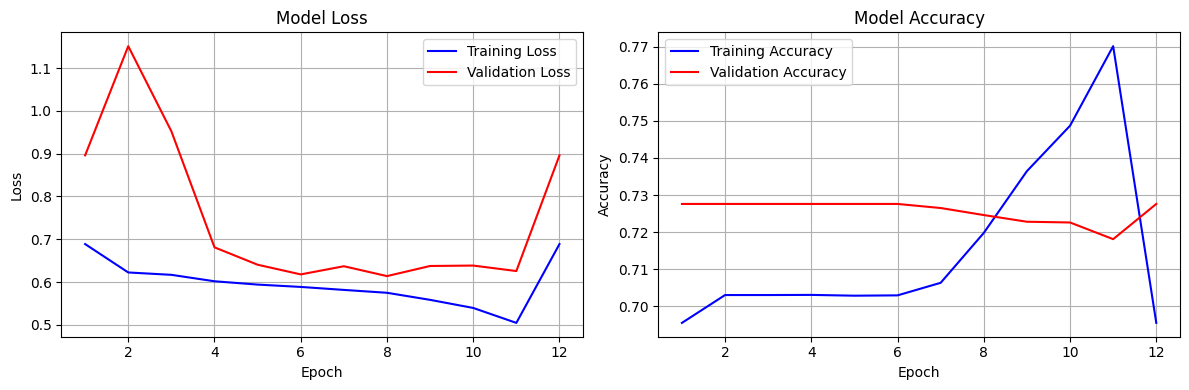

In [14]:
if True:
    for name, model in [
        ("binary_model", binary_model)
    ]:

        tags = {
            "model_type": "neural_network",
            "task": "rating_prediction",
            "dataset": "amazon_reviews",
            "variant": name
        }
 
        exp = model.log_training_history(
            run_name=f"{name}_{model.input_shape}features",
            tags=tags
        )

        print(exp)

        _ = model.plot_training_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_{name}.png"
        )


## Cargar modelo


In [15]:
from src.utils.models import BinaryModel
binary_model = BinaryModel('binary_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")
binary_model.load_latest_model()


/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [16]:
binary_model.list_available_models()



Available Model Versions (filtered by: binary_model)

1. Run ID: 195df4651b0e4630bb7a59963e15babe
   Run Name: binary_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-20 01:24:18.123000+00:00
   End Time: 2025-10-20 01:24:32.448000+00:00
   Metrics: Loss: 0.5044, Val Loss: 0.6257, Accuracy: 0.7702, Val Accuracy: 0.7181

2. Run ID: da3b31aaa4664d86a48d473d0d937d68
   Run Name: binary_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-19 18:27:54.745000+00:00
   End Time: 2025-10-19 18:28:08.397000+00:00
   Metrics: Loss: 0.0442, Val Loss: 0.0161, Accuracy: 0.9912, Val Accuracy: 1.0000

3. Run ID: a37b31c6482c44ce9b6feece646ba2cf
   Run Name: binary_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-19 14:45:07.116000+00:00
   End Time: 2025-10-19 14:45:17.536000+00:00
   Metrics: Loss: 0.3411, Val Loss: 0.5678, Accuracy: 0.8900, Val Accuracy: 0.6733

4. Run ID: 74fc9bd2c7a2466b840dc65d0a564833
   Run Nam